In [2]:
import sys, pandas as pd, numpy as np
sys.path.append('src')
from plot_style import set_publication_style
set_publication_style()

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('data/cleaned_data.csv')
log_cols = [c for c in df.columns if c.endswith('_log')]

C:\Users\dilini.eakanayake\AppData\Local\Temp\ipykernel_23412\1909692408.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='behavior_group', y=top_var, ax=axes[1,0],


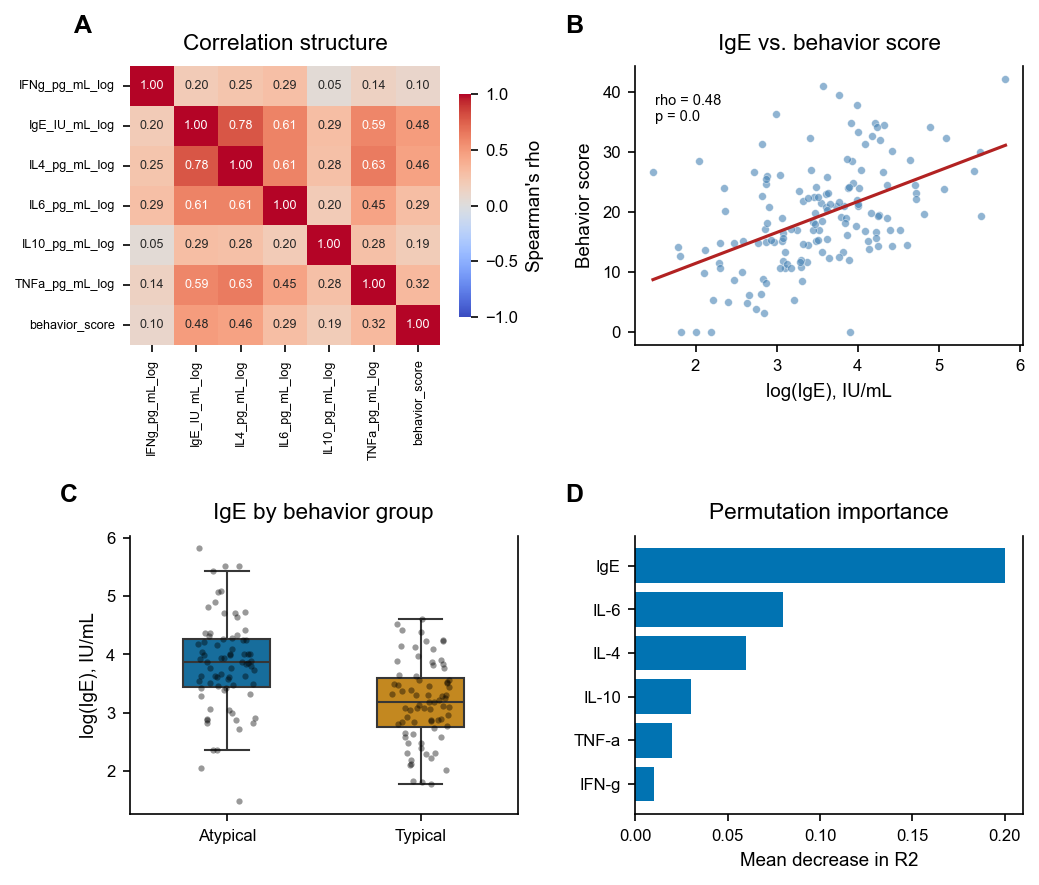

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(7.0, 6.0))

# Panel A: correlation heatmap
corr = df[log_cols + ['behavior_score']].corr(method='spearman')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
ax=axes[0,0], cbar_kws={'label': "Spearman's rho", 'shrink': 0.8},
annot_kws={'size': 6})
axes[0,0].set_title('Correlation structure', pad=8)
axes[0,0].tick_params(axis='both', labelsize=6)

# Panel B: scatter of top predictor vs outcome, with regression line (built manually)
top_var = 'IgE_IU_mL_log'
x_vals = df[top_var].values
y_vals = df['behavior_score'].values

axes[0,1].scatter(x_vals, y_vals, s=14, alpha=0.6, edgecolor='white', linewidth=0.3, color='steelblue')

slope, intercept = np.polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
y_line = slope * x_line + intercept
axes[0,1].plot(x_line, y_line, color='firebrick', linewidth=1.5)

rho, p = stats.spearmanr(x_vals, y_vals)
axes[0,1].set_title('IgE vs. behavior score', pad=8)
axes[0,1].set_xlabel('log(IgE), IU/mL')
axes[0,1].set_ylabel('Behavior score')
axes[0,1].annotate('rho = ' + str(round(rho, 2)) + '\np = ' + str(round(p, 3)),
xy=(0.05, 0.90), xycoords='axes fraction', fontsize=7, va='top')

# Panel C: group comparison boxplot with individual points overlaid
sns.boxplot(data=df, x='behavior_group', y=top_var, ax=axes[1,0],
width=0.45, showfliers=False, palette='colorblind')
sns.stripplot(data=df, x='behavior_group', y=top_var, ax=axes[1,0],
size=3, color='black', alpha=0.4, jitter=0.15)
axes[1,0].set_title('IgE by behavior group', pad=8)
axes[1,0].set_ylabel('log(IgE), IU/mL')
axes[1,0].set_xlabel('')

# Panel D: model feature importance (placeholder - replace with your real perm_df later)
importance_example = pd.DataFrame({
'variable': ['IgE', 'IL-4', 'IL-6', 'IL-10', 'TNF-a', 'IFN-g'],
'importance': [0.20, 0.06, 0.08, 0.03, 0.02, 0.01]
}).sort_values('importance')
axes[1,1].barh(importance_example['variable'], importance_example['importance'],
color=sns.color_palette('colorblind')[0])
axes[1,1].set_title('Permutation importance', pad=8)
axes[1,1].set_xlabel('Mean decrease in R2')

# Add panel labels A, B, C, D
for ax, label in zip(axes.flatten(), ['A', 'B', 'C', 'D']):
    ax.text(-0.18, 1.12, label, transform=ax.transAxes, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('results/Figure1_summary.pdf')
plt.savefig('results/Figure1_summary.png', dpi=300)
plt.show()